In [ ]:
from google.colab import files
uploaded = files.upload()

Saving rainfall_temperature_yield_sample_data (1).xlsx to rainfall_temperature_yield_sample_data (1) (3).xlsx


   Rainfall_mm Temperature_C  Yield_ton_per_ha  Unnamed: 3 train/test
0      1061.81         15.63              4.44         NaN      train
1      1926.07         27.73              4.81         NaN        NaN
2      1597.99         21.29              5.15         NaN        NaN
3      1397.99         25.17              3.66         NaN        NaN
4       734.03         33.15              2.43         NaN        NaN
MAE: 0.366864957800055
MSE: 0.16680026252400465
RMSE: 0.4084118785295117
MAPE: 10.643226664691621
R Squared: 0.8860953488843408


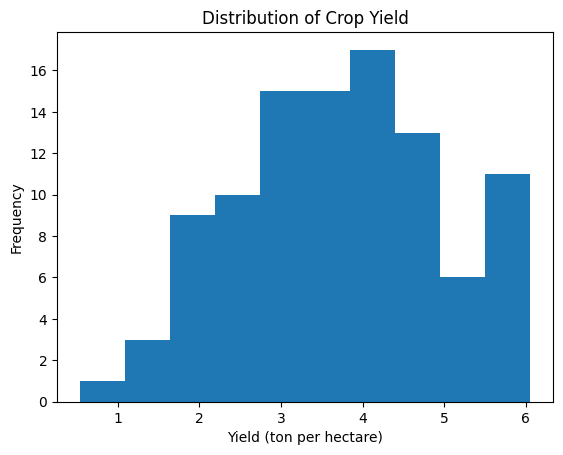

Cross Validation R2 Scores: [0.87701817 0.86501421 0.83543118 0.76788702 0.82561021]
Average R2 Score: 0.8341921570782436


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Read the dataset from Excel file
data = pd.read_excel("rainfall_temperature_yield_sample_data (1) (3).xlsx")

# Rename the first column to 'Rainfall_mm' as it appears to be unnamed
# We are assuming the first column (index 0) contains the rainfall data
data.rename(columns={data.columns[0]: 'Rainfall_mm'}, inplace=True)

# Convert 'Yield_ton_per_ha' to numeric, coercing errors to NaN
data['Yield_ton_per_ha'] = pd.to_numeric(data['Yield_ton_per_ha'], errors='coerce')

# Drop rows where 'Yield_ton_per_ha' is NaN
data.dropna(subset=['Yield_ton_per_ha'], inplace=True)

# Display first few rows
print(data.head())

# Independent variables (features)
X = data[['Rainfall_mm', 'Temperature_C']]

# Dependent variable (target)
y = data['Yield_ton_per_ha']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create linear regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Predict yield values using test data
y_pred = model.predict(X_test)

# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# Mean Absolute Percentage Error
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# R Squared
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAPE:", mape)
print("R Squared:", r2)

# Plot histogram of yield values
plt.hist(y, bins=10)
plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (ton per hectare)")
plt.ylabel("Frequency")
plt.show()

from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print("Cross Validation R2 Scores:", scores)
print("Average R2 Score:", scores.mean())